<a href="https://colab.research.google.com/github/amalendukithu06-cyber/DSA/blob/main/Supervised_Learning_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score

Read Dataset

In [84]:
train = pd.read_csv("Training_data.csv")
test = pd.read_csv("Testing_data.csv")

View Dataset

In [85]:
train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [86]:
train.shape

(5634, 21)

In [87]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [88]:
train.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


Check Missing Values

In [89]:
train.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


Check Duplicate Rows

Remove Duplicate Rows

In [90]:
train.duplicated().sum()

np.int64(0)

In [91]:
train.drop_duplicates(inplace=True)

Target Variable Distribution

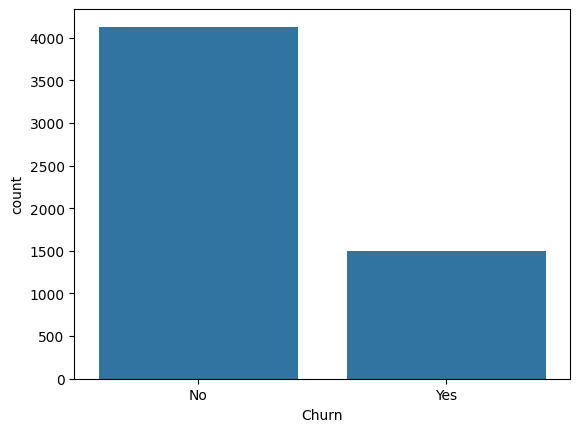

In [92]:
sns.countplot(x="Churn",data=train)
plt.show()

Numerical columns Distribution

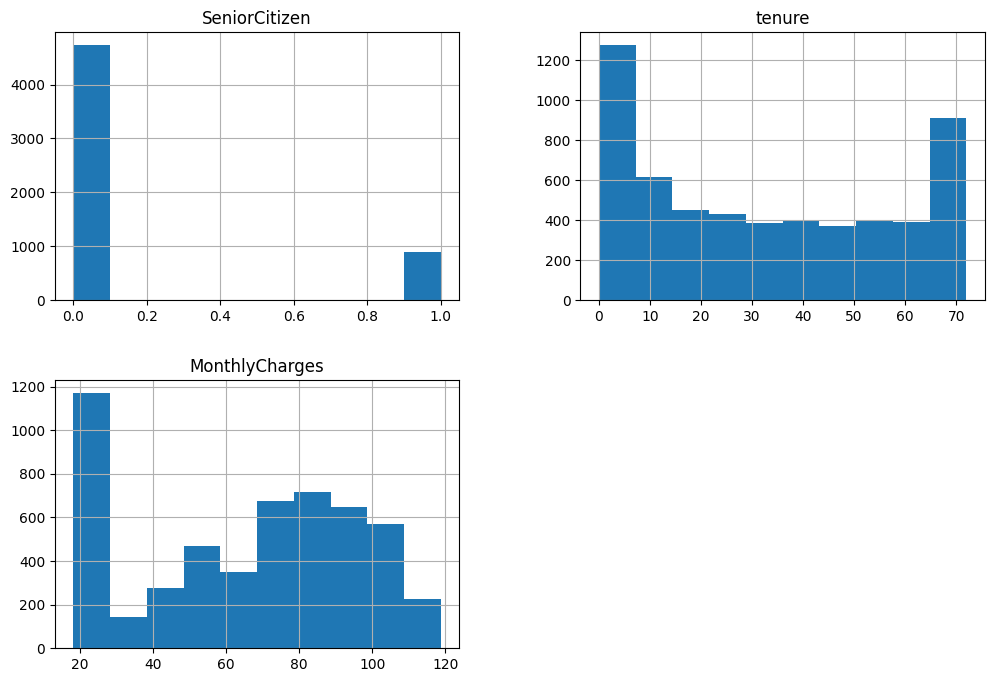

In [93]:
num_cols=train.select_dtypes(include=np.number).columns

train[num_cols].hist(figsize=(12,8))
plt.show()

Correlation Heatmap

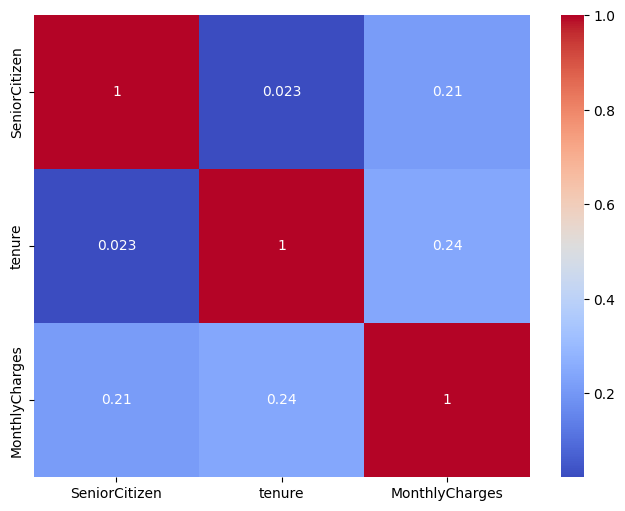

In [94]:
plt.figure(figsize=(8,6))
sns.heatmap(train[num_cols].corr(),annot=True,cmap="coolwarm")
plt.show()

BoxPlot for Outliers

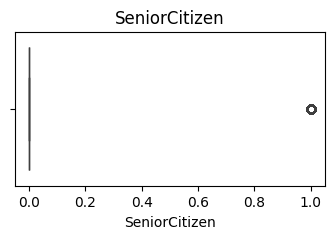

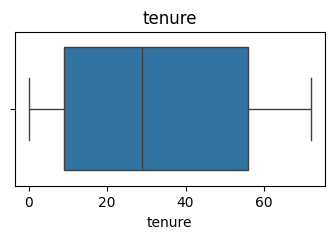

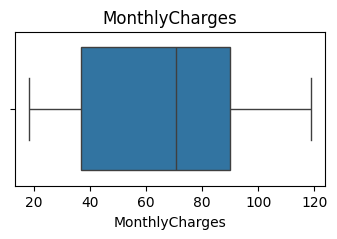

In [95]:
for col in num_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=train[col])
    plt.title(col)
    plt.show()

Convert Total Charges

In [96]:
train["TotalCharges"]=pd.to_numeric(train["TotalCharges"],errors="coerce")
test["TotalCharges"]=pd.to_numeric(test["TotalCharges"],errors="coerce")

Feature Engineering

In [97]:
train["CustomerLifetimeValue"]=train["tenure"]*train["MonthlyCharges"]

test["CustomerLifetimeValue"]=test["tenure"]*test["MonthlyCharges"]

Separate X and Y

In [98]:
X=train.drop(["customerID","Churn"],axis=1)

y=train["Churn"]

In [99]:
X_test=test.drop(["customerID"],axis=1)

Identify Numerical & Categorical Columns

In [100]:
numeric_features=X.select_dtypes(include=np.number).columns

categorical_features=X.select_dtypes(include="object").columns

PreProcessing Pipeline

In [101]:
numeric_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

In [102]:
categorical_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

In [103]:
preprocessor=ColumnTransformer([
    ("num",numeric_transformer,numeric_features),
    ("cat",categorical_transformer,categorical_features)
])

Train Test Split

In [104]:
X_train,X_valid,y_train,y_valid=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Logistic Regression

In [105]:
lr_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'CustomerLifetimeValue'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [147]:
#Prediction
pred_lr=lr_pipeline.predict(X_valid)
#Prediction methods used:
# 1. Logistic Regression (lr_pipeline)
# 2. Random Forest Classifier (rf_pipeline)
# 3. Gradient Boosting Classifier (gb_pipeline)
# 4. Hyperparameter tuned Random Forest Classifier (best_model) - for final test predictions

In [107]:
#Accuracy
print("Accuracy:",accuracy_score(y_valid,pred_lr))

Accuracy: 0.8039041703637977


In [108]:
#Classification Report
print(classification_report(y_valid,pred_lr))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87       826
         Yes       0.65      0.57      0.61       301

    accuracy                           0.80      1127
   macro avg       0.75      0.73      0.74      1127
weighted avg       0.80      0.80      0.80      1127



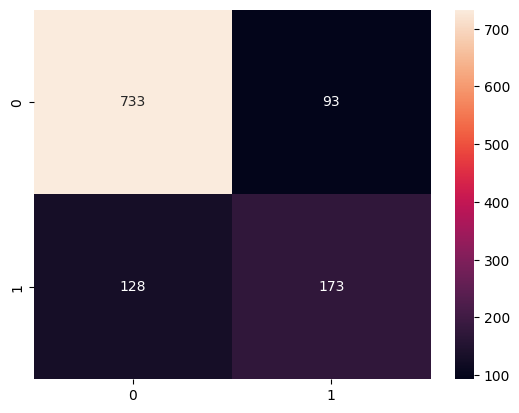

In [109]:
#ConfusionMatrix
sns.heatmap(confusion_matrix(y_valid,pred_lr),
            annot=True,
            fmt='d')

plt.show()

In [110]:
#ROC AUC
prob_lr=lr_pipeline.predict_proba(X_valid)[:,1]

print("ROC AUC:",roc_auc_score(y_valid.map({"No":0,"Yes":1}),prob_lr))

ROC AUC: 0.8461705533612736


Random Forest

In [111]:
rf_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train,y_train)

pred_rf=rf_pipeline.predict(X_valid)

print("Accuracy:",accuracy_score(y_valid,pred_rf))

print(classification_report(y_valid,pred_rf))

Accuracy: 0.8003549245785271
              precision    recall  f1-score   support

          No       0.84      0.90      0.87       826
         Yes       0.66      0.52      0.58       301

    accuracy                           0.80      1127
   macro avg       0.75      0.71      0.73      1127
weighted avg       0.79      0.80      0.79      1127



Gradient Boosting

In [112]:
gb_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",GradientBoostingClassifier(random_state=42))
])

gb_pipeline.fit(X_train,y_train)

pred_gb=gb_pipeline.predict(X_valid)

print("Accuracy:",accuracy_score(y_valid,pred_gb))

print(classification_report(y_valid,pred_gb))

Accuracy: 0.8189884649511979
              precision    recall  f1-score   support

          No       0.86      0.91      0.88       826
         Yes       0.69      0.58      0.63       301

    accuracy                           0.82      1127
   macro avg       0.77      0.74      0.76      1127
weighted avg       0.81      0.82      0.81      1127



Hyper Parameter Tuning

In [113]:
from sklearn.model_selection import GridSearchCV

param_grid={
    "model__n_estimators":[100,200],
    "model__max_depth":[5,10],
    "model__min_samples_split":[2,5]
}

grid=GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

print(grid.best_params_)

print(grid.best_score_)

{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
0.7969816734793319


In [114]:
#BestModel
best_model=grid.best_estimator_

In [115]:
#Predict testing Dataset
test_prediction=best_model.predict(X_test)

In [116]:
#Submission File
submission=pd.DataFrame({
    "CustomerID":test["customerID"],
    "Churn":test_prediction
})

submission.head()

,CustomerID,Churn
0,6080-TCMYC,No
1,7285-KLOTR,No
2,7486-KSRVI,No
3,9924-JPRMC,No
4,4439-YRNVD,No


In [117]:
submission.to_csv("Customer_Churn_Predictions.csv",index=False)

In [118]:
from google.colab import files

files.download("Customer_Churn_Predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [119]:
train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerLifetimeValue
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No,726.25
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No,1001.00
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No,5521.60
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No,797.55
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No,2203.75


In [120]:
train.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerLifetimeValue
5629,5649-RXQTV,Male,0,No,No,51,Yes,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No,5049.00
5630,3908-MKIMJ,Male,1,Yes,No,68,No,No phone service,DSL,Yes,...,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No,2852.60
5631,4277-BWBML,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No,1436.40
5632,9110-HSGTV,Female,0,No,No,69,Yes,No,DSL,NaN,...,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No,5689.05
5633,3402-XRIUO,NaN,1,Yes,No,22,Yes,Yes,DSL,Yes,...,Yes,No,No,Month-to-month,Yes,Mailed check,63.55,1381.80,No,1398.10


In [121]:
train.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerLifetimeValue
5217,3836-FZSDJ,Male,1,Yes,No,71,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),24.85,1901.00,No,1764.35
3259,6925-BAYGL,Female,1,Yes,No,53,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.10,1275.60,No,1330.30
2690,0661-KBKPA,Male,0,Yes,Yes,53,Yes,Yes,DSL,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,78.75,3942.45,No,4173.75
1812,1465-VINDH,Female,0,Yes,Yes,10,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),102.10,1068.85,Yes,1021.00
2541,7250-EQKIY,Female,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,Month-to-month,No,Mailed check,50.45,50.45,Yes,50.45


In [122]:
train.shape

(5634, 22)

In [123]:
train.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'CustomerLifetimeValue'],
      dtype='object')

In [124]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customerID             5634 non-null   object 
 1   gender                 5465 non-null   object 
 2   SeniorCitizen          5634 non-null   int64  
 3   Partner                5634 non-null   object 
 4   Dependents             5634 non-null   object 
 5   tenure                 5634 non-null   int64  
 6   PhoneService           5634 non-null   object 
 7   MultipleLines          5634 non-null   object 
 8   InternetService        5634 non-null   object 
 9   OnlineSecurity         5465 non-null   object 
 10  OnlineBackup           5634 non-null   object 
 11  DeviceProtection       5634 non-null   object 
 12  TechSupport            5634 non-null   object 
 13  StreamingTV            5634 non-null   object 
 14  StreamingMovies        5634 non-null   object 
 15  Cont

In [125]:
train.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,CustomerLifetimeValue
count,5634.000000,5634.000000,5240.000000,5344.000000,5240.000000
mean,0.159744,32.606851,65.102052,2283.932279,2307.124952
std,0.366401,24.614976,30.056443,2266.719324,2278.812254
min,0.000000,0.000000,18.250000,18.850000,0.000000
25%,0.000000,9.000000,36.800000,406.612500,400.687500
50%,0.000000,29.000000,70.650000,1396.450000,1408.050000
75%,0.000000,56.000000,90.050000,3778.362500,3844.775000
max,1.000000,72.000000,118.750000,8684.800000,8550.000000


In [126]:
train.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,5634,5465,5634,5634,5634,5634,5634,5465,5634,5634,5634,5634,5634,5634,5634,5634,5634
unique,5634,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3402-XRIUO,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,2744,2890,3960,5081,2701,2486,2720,2459,2485,2782,2244,2232,3094,3350,1892,4130


In [127]:
train.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [128]:
train.duplicated().sum()

np.int64(0)

In [129]:
train.drop_duplicates(inplace=True)

In [130]:
train.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [131]:
#Convert total charges
train["TotalCharges"]=pd.to_numeric(train["TotalCharges"],errors="coerce")

In [132]:
train.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [133]:
for col in train.columns:
    print(col)
    print(train[col].unique())

customerID
['9509-MPYOD' '7746-AWNQW' '2208-UGTGR' ... '4277-BWBML' '9110-HSGTV'
 '3402-XRIUO']
gender
['Female' 'Male' nan]
SeniorCitizen
[0 1]
Partner
['No' 'Yes']
Dependents
['No' 'Yes']
tenure
[35 28 56 39 43  2 18 63 40 53 48 72 61  6 21  9  3 58 57 17 30 20  4 16
 71 38  5 13 55 60 37  1  7 11 12 67 54  8 22 65 36 50 23 49 69 70 25 14
 10 52 68 33 24 66 59 32 27 29 45 42 64 62 19 41 51 44 34 26 47 31 15 46
  0]
PhoneService
['Yes' 'No']
MultipleLines
['No' 'No phone service' 'Yes']
InternetService
['No' 'DSL' 'Fiber optic']
OnlineSecurity
['No internet service' 'No' nan 'Yes']
OnlineBackup
['No internet service' 'No' 'Yes']
DeviceProtection
['No internet service' 'Yes' 'No']
TechSupport
['No internet service' 'Yes' 'No']
StreamingTV
['No internet service' 'No' 'Yes']
StreamingMovies
['No internet service' 'No' 'Yes']
Contract
['One year' 'Month-to-month' 'Two year']
PaperlessBilling
['No' 'Yes']
PaymentMethod
['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit

In [134]:
train["Contract"].value_counts()

,count
Contract,
Month-to-month,3094
Two year,1368
One year,1172


<Axes: xlabel='Churn', ylabel='count'>

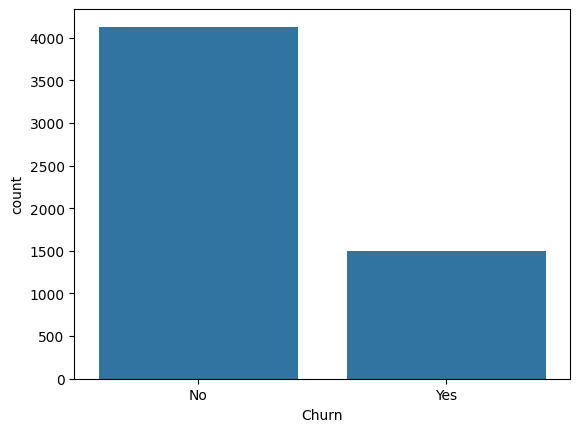

In [135]:
sns.countplot(x="Churn",data=train)

<Axes: ylabel='count'>

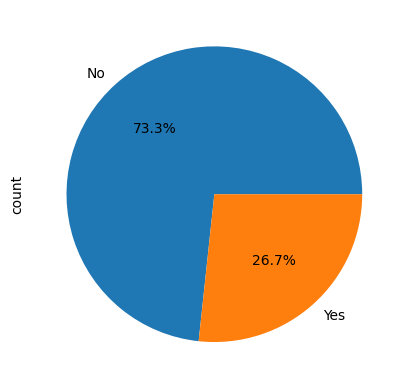

In [136]:
#pie chart
train["Churn"].value_counts().plot.pie(autopct="%1.1f%%")

<Axes: xlabel='gender', ylabel='count'>

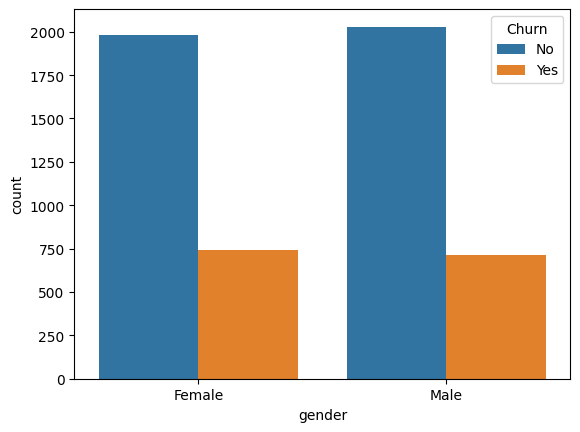

In [137]:
#Gender
sns.countplot(x="gender",hue="Churn",data=train)

<Axes: xlabel='Contract', ylabel='count'>

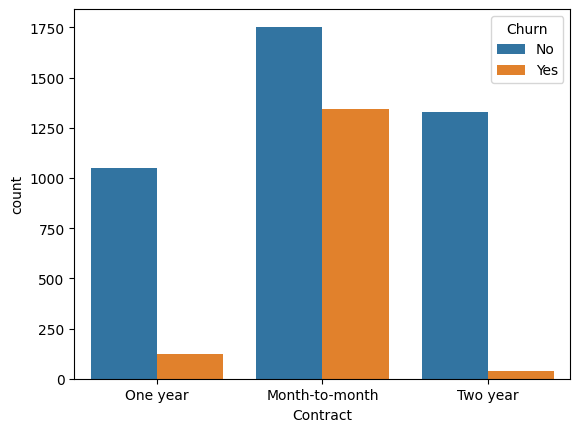

In [138]:
#Contract
sns.countplot(x="Contract",hue="Churn",data=train)

<Axes: xlabel='InternetService', ylabel='count'>

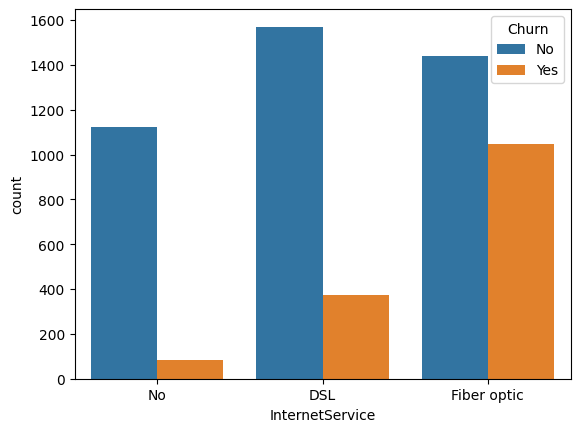

In [139]:
#Internet Service
sns.countplot(x="InternetService",hue="Churn",data=train)

<Axes: xlabel='PaymentMethod', ylabel='count'>

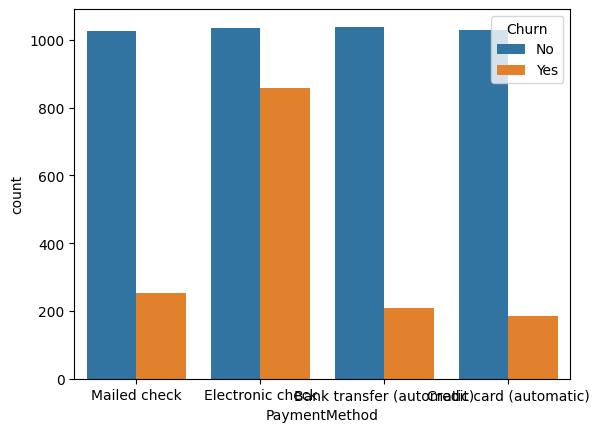

In [140]:
#Payment Method
sns.countplot(x="PaymentMethod",hue="Churn",data=train)

<Axes: xlabel='SeniorCitizen', ylabel='count'>

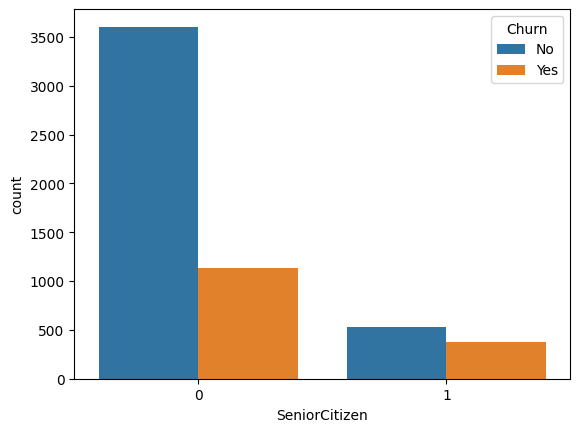

In [141]:
#Senior Citizen
sns.countplot(x="SeniorCitizen",hue="Churn",data=train)

array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>],
       [<Axes: title={'center': 'CustomerLifetimeValue'}>, <Axes: >]],
      dtype=object)

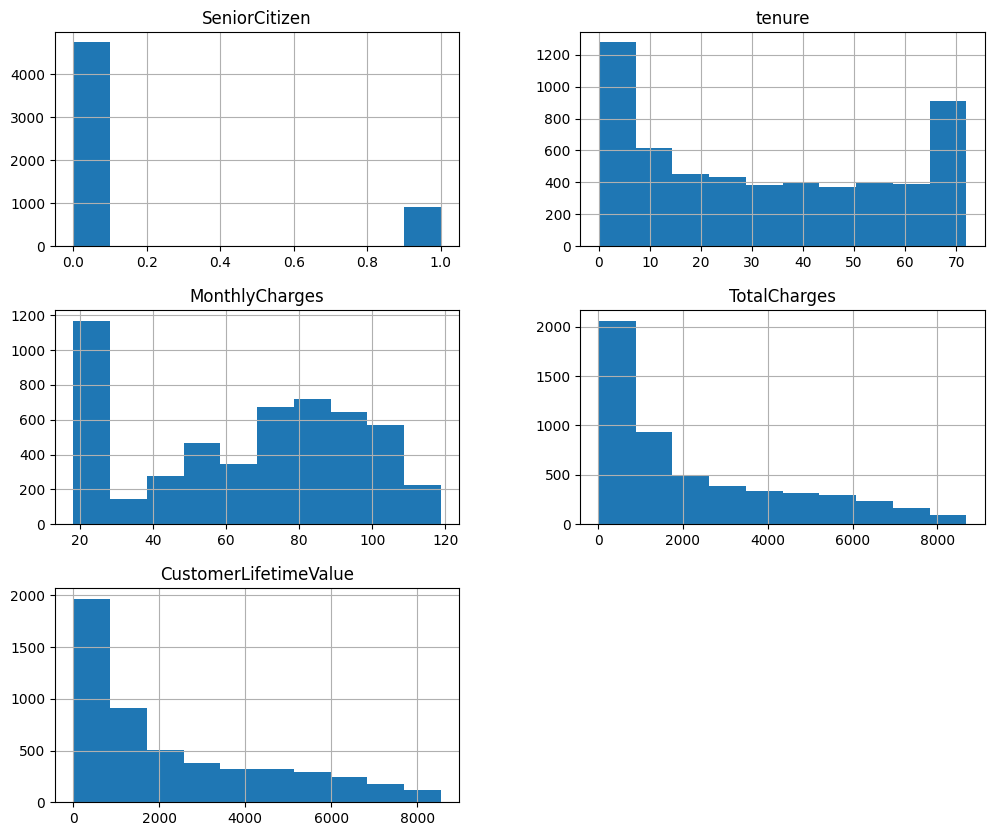

In [142]:
#Histograms
train.hist(figsize=(12,10))

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

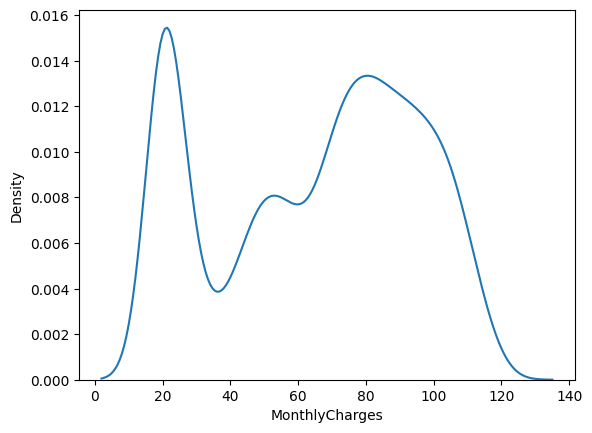

In [143]:
#KDE Plot
sns.kdeplot(train["MonthlyCharges"])

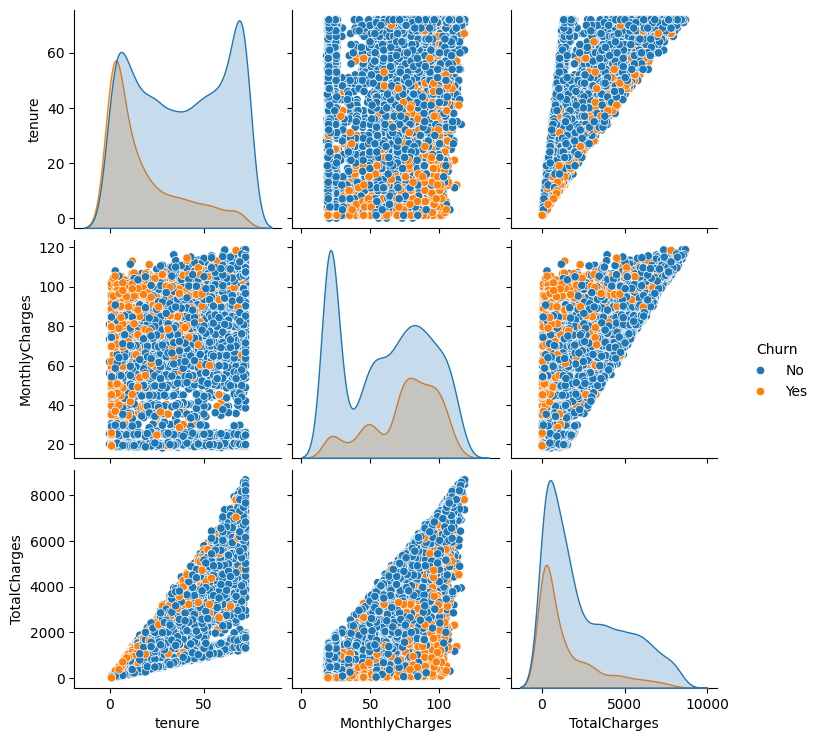

In [144]:
#PairPlot
sns.pairplot(train[["tenure","MonthlyCharges","TotalCharges","Churn"]],hue="Churn")

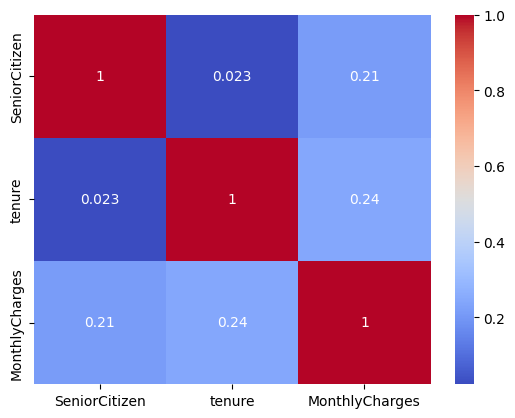

In [145]:
#Correlation Heatmap
sns.heatmap(train[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

In [146]:
print(train.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'CustomerLifetimeValue'],
      dtype='object')


In [148]:
print(test.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'CustomerLifetimeValue'],
      dtype='object')
